# AI Product Intelligence System — Day 2 Extension
| github.com/DevPathak18**

This notebook extends the Day 1 product-understanding system with three advanced features, all built on a shared **CLIP embedding backbone**:

| Task | Feature | Core idea |
|---|---|---|
| 1 | Smart Product Recommendation Engine | Suggest *complementary* products (bought together), not just visually similar ones |
| 2 | Unique Product Catalog Creation | Detect and remove duplicate/near-duplicate product listings |
| 3 | Reverse Product Search | Search the catalog using a **text** query instead of an image |

**Dataset:** [Fashion Product Images (Small)](https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small) — ~44,000 products, each with a `styles.csv` metadata row and a corresponding image in `images/<id>.jpg`.

**Why CLIP:** CLIP maps both images and text into the *same* embedding space, so we can compare image-to-image, text-to-image, and text-to-text similarity with one model — which is exactly what the assignment hint points at.


## 0. Setup

In [ ]:

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Torch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


In [ ]:

!pip install -q open_clip_torch
import open_clip


In [ ]:


!pip install -q kagglehub
import kagglehub

DATASET_DIR = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
print("Dataset downloaded to:", DATASET_DIR)
print("Contents:", os.listdir(DATASET_DIR))


Dataset downloaded to: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small
Contents: ['myntradataset', 'images', 'styles.csv']


In [ ]:

def find_file(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return dirpath
    return None

base_dir = find_file(DATASET_DIR, "styles.csv")
if base_dir is None:
    raise FileNotFoundError("Could not locate styles.csv under the downloaded dataset.")

IMAGES_DIR = os.path.join(base_dir, "images")
STYLES_CSV = os.path.join(base_dir, "styles.csv")

print("Dataset dir exists:", os.path.exists(DATASET_DIR))
print("Images dir exists:", os.path.exists(IMAGES_DIR))
print("styles.csv exists:", os.path.exists(STYLES_CSV))


Dataset dir exists: True
Images dir exists: True
styles.csv exists: True


## 1. Load & Clean the Product Metadata

`styles.csv` sometimes has malformed rows (extra commas inside product names), so we load it defensively with `on_bad_lines="skip"`, then keep only rows whose image file actually exists on disk.


In [15]:
df = pd.read_csv(STYLES_CSV, on_bad_lines="skip")
print("Rows loaded:", len(df))
df.head()


Rows loaded: 44424


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:

df = df.dropna(subset=["id", "productDisplayName", "articleType"]).copy()
df["id"] = df["id"].astype(int)

def image_path(pid):
    return os.path.join(IMAGES_DIR, f"{pid}.jpg")

df["image_path"] = df["id"].apply(image_path)
df["image_exists"] = df["image_path"].apply(os.path.exists)
df = df[df["image_exists"]].reset_index(drop=True)

print("Usable products:", len(df))
df[["id", "gender", "masterCategory", "subCategory", "articleType", "baseColour", "productDisplayName"]].head()


Usable products: 44412


,id,gender,masterCategory,subCategory,articleType,baseColour,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Puma Men Grey T-shirt


In [ ]:

SAMPLE_SIZE = 6000
if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print("Working with", len(df), "products")
df["masterCategory"].value_counts()


Working with 6000 products


masterCategory
Apparel           2871
Accessories       1549
Footwear          1246
Personal Care      315
Free Items          14
Sporting Goods       5
Name: count, dtype: int64

## 2. Build CLIP Embeddings (shared backbone for all 3 tasks)

We load a pretrained CLIP model (`ViT-B-32`) and compute one image embedding per product. These embeddings are the foundation for:
- **Task 3** — comparing a text query embedding against all image embeddings
- **Task 2** — finding near-duplicate products via embedding similarity
- **Task 1** — partly informed by embedding similarity between category names

We cache embeddings to disk so we don't have to recompute them if the notebook is re-run.


In [18]:
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
tokenizer = open_clip.get_tokenizer("ViT-B-32")
model = model.to(DEVICE).eval()
print("CLIP model loaded.")


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP model loaded.


In [ ]:
EMBED_CACHE = "image_embeddings.npy"

@torch.no_grad()
def embed_images(paths, batch_size=64):
    """Compute L2-normalized CLIP image embeddings for a list of image paths."""
    all_embeds = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB")
            except Exception:
                img = Image.new("RGB", (224, 224))
            imgs.append(preprocess(img))
        batch = torch.stack(imgs).to(DEVICE)
        feats = model.encode_image(batch)
        feats = F.normalize(feats, dim=-1)
        all_embeds.append(feats.cpu().numpy())
        if i % (batch_size * 10) == 0:
            print(f"Embedded {i + len(batch_paths)}/{len(paths)} images")
    return np.concatenate(all_embeds, axis=0)

if os.path.exists(EMBED_CACHE):
    image_embeddings = np.load(EMBED_CACHE)
    if len(image_embeddings) != len(df):
        print(f"Cached embeddings ({len(image_embeddings)}) don't match current dataframe "
              f"({len(df)}) — likely SAMPLE_SIZE changed since the cache was written. Recomputing.")
        image_embeddings = embed_images(df["image_path"].tolist())
        np.save(EMBED_CACHE, image_embeddings)
        print("Computed and cached embeddings:", image_embeddings.shape)
    else:
        print("Loaded cached embeddings:", image_embeddings.shape)
else:
    image_embeddings = embed_images(df["image_path"].tolist())
    np.save(EMBED_CACHE, image_embeddings)
    print("Computed and cached embeddings:", image_embeddings.shape)


df["embed_idx"] = np.arange(len(df))


Loaded cached embeddings: (6000, 512)


In [ ]:
@torch.no_grad()
def embed_text(texts):
    """Compute L2-normalized CLIP text embeddings for a list of strings."""
    tokens = tokenizer(texts).to(DEVICE)
    feats = model.encode_text(tokens)
    feats = F.normalize(feats, dim=-1)
    return feats.cpu().numpy()


test_vec = embed_text(["a pair of running shoes"])
print("Text embedding shape:", test_vec.shape)


Text embedding shape: (1, 512)


---
## Task 3 — Reverse Product Search (text → image)

**Problem:** instead of searching with an image, let the user type a text description and get back matching products.

**How it works:** CLIP embeds text and images into the same vector space. So we embed the user's query text the same way we embedded the product images, then rank every product by **cosine similarity** between the query embedding and that product's image embedding. Since both embeddings are L2-normalized, cosine similarity is just a dot product.


In [ ]:
def reverse_search(query, top_k=5):
    query_vec = embed_text([query])[0]              
    sims = image_embeddings @ query_vec              
    top_idx = np.argsort(-sims)[:top_k]
    results = df.iloc[top_idx].copy()
    results["similarity"] = sims[top_idx]
    return results[["id", "productDisplayName", "articleType", "baseColour", "similarity", "image_path"]]

results = reverse_search("blue casual shirt", top_k=5)
results


,id,productDisplayName,articleType,baseColour,similarity,image_path
4833,32391,Arrow Woman Blue Shirt,Shirts,Blue,0.308482,/kaggle/input/datasets/paramaggarwal/fashion-p...
1452,22400,Mark Taylor Men Blue Shirt,Shirts,Blue,0.304950,/kaggle/input/datasets/paramaggarwal/fashion-p...
2431,7145,Scullers For Her Women Light Work Navy Blue Sh...,Shirts,Navy Blue,0.304740,/kaggle/input/datasets/paramaggarwal/fashion-p...
2624,26958,Jealous 21 Women Teal Shirt,Shirts,Teal,0.301982,/kaggle/input/datasets/paramaggarwal/fashion-p...
248,39798,Peter England Men Blue Formal Shirt,Shirts,Blue,0.301281,/kaggle/input/datasets/paramaggarwal/fashion-p...


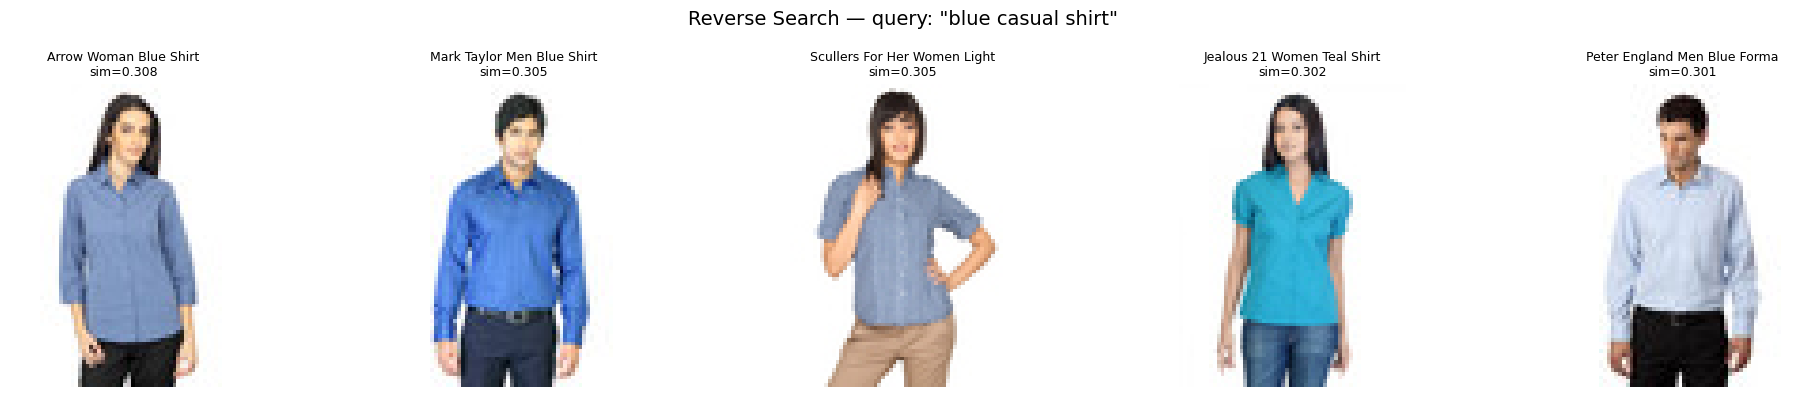

In [22]:
def show_search_results(query, results):
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
    fig.suptitle(f'Reverse Search — query: "{query}"', fontsize=14)
    for ax, (_, row) in zip(axes, results.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f'{row["productDisplayName"][:28]}\nsim={row["similarity"]:.3f}', fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_search_results("blue casual shirt", results)


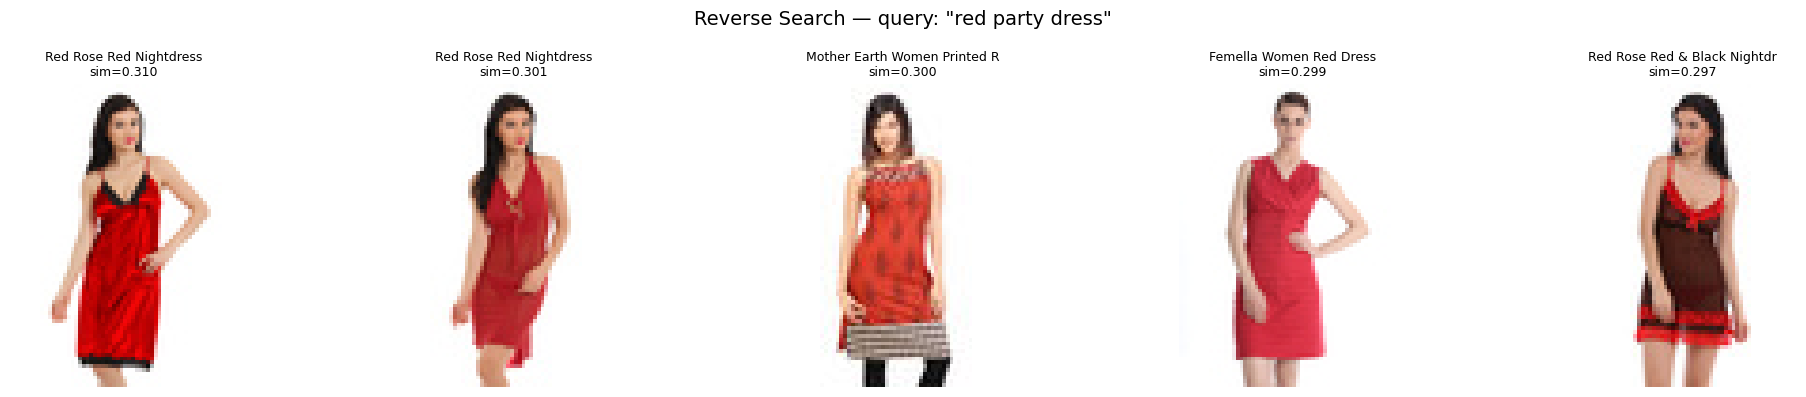

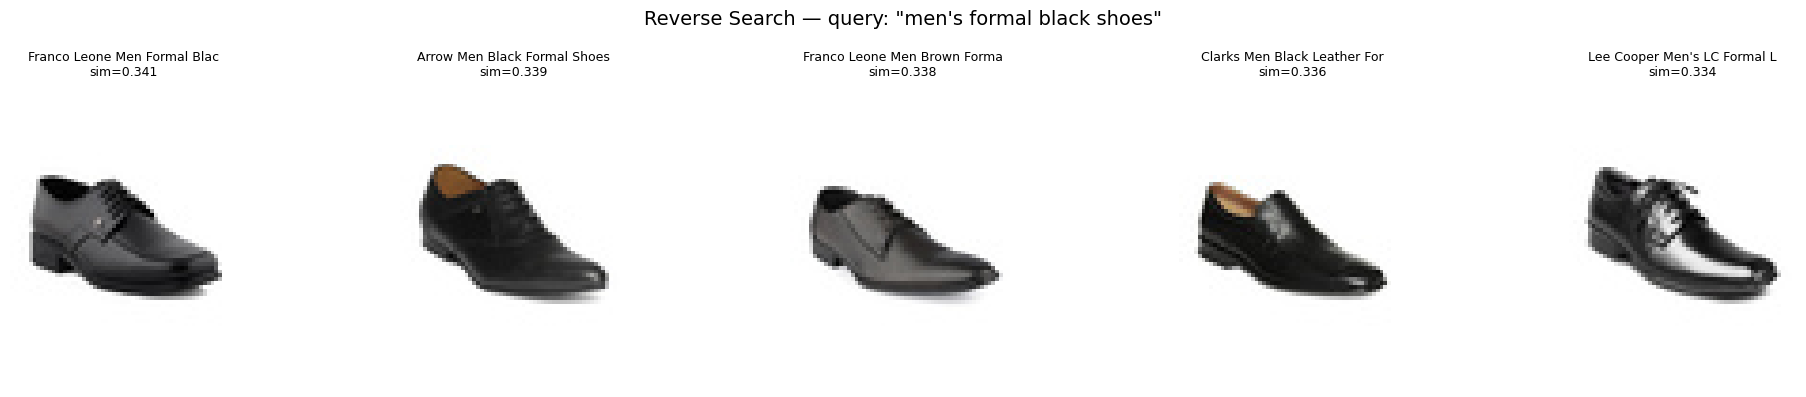

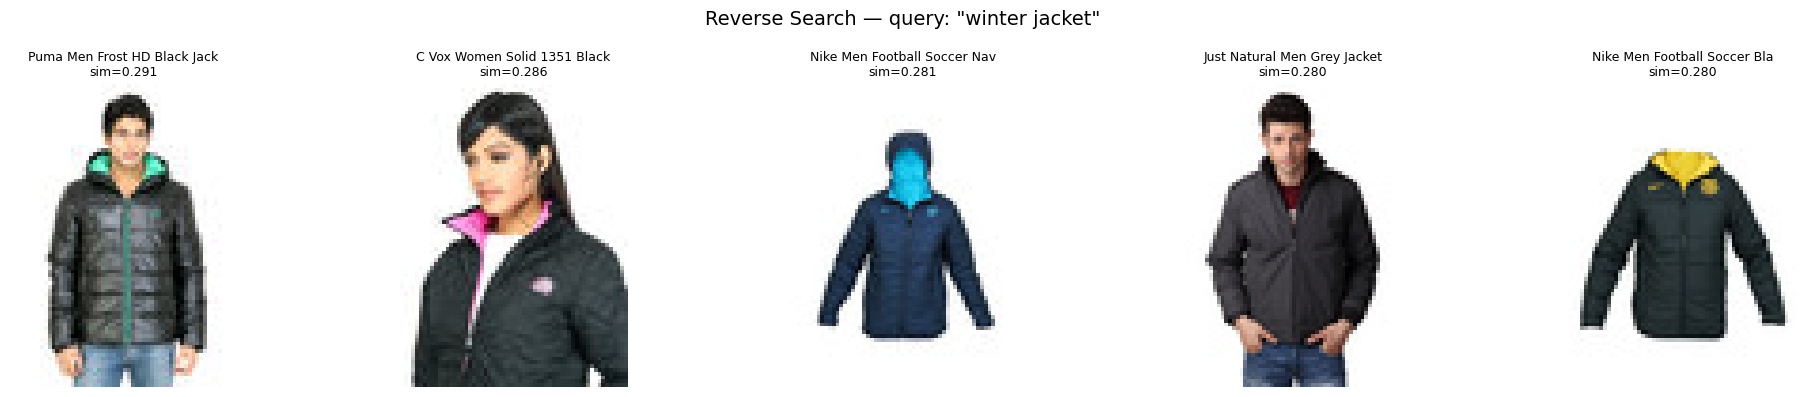

In [23]:
# A couple more example queries to demonstrate robustness
for q in ["red party dress", "men's formal black shoes", "winter jacket"]:
    res = reverse_search(q, top_k=5)
    show_search_results(q, res)


---
## Task 2 — Unique Product Catalog Creation

**Problem:** different sellers often upload near-identical products (same shirt, different photo/listing). We want a clean catalog with one entry per *visually distinct* product.

**Approach:**
1. Use the same CLIP image embeddings.
2. For products within the same `articleType` (comparing across totally different categories isn't meaningful here), compute pairwise cosine similarity.
3. Treat a pair as a likely duplicate only if **both** conditions hold: (a) image embedding similarity is above a high threshold, **and** (b) they share the same `baseColour` and a closely matching `productDisplayName`. Image similarity alone isn't enough here — these product photos are small (80x60px), studio-shot, mostly plain backgrounds, so CLIP's embedding picks up a lot of "generic shirt-on-model" similarity between genuinely different products. Adding the metadata check filters that noise out.
4. Group duplicate pairs together — but **not** with plain transitive grouping. If A is a duplicate of B, and B is a duplicate of C, that does not guarantee A is a duplicate of C (e.g. two different shoe styles can each be borderline-similar to a third shoe in between, without being similar to each other). So a new product only joins an existing group if it's a duplicate of *every* product already in that group, keeping each group a genuine mutual match rather than a loosely chained one.
5. Keep one representative per group → this becomes the unique catalog.

We restrict comparisons to the same `articleType` for speed (avoids an all-vs-all O(n^2) comparison across 6,000+ items) and because it's the realistic assumption: a t-shirt and a shoe are never duplicates of each other.


Pairwise similarity stats within 'Tshirts' (n=940 products):
  mean=0.810  median=0.814  95th pct=0.897  99th pct=0.922  max=1.000


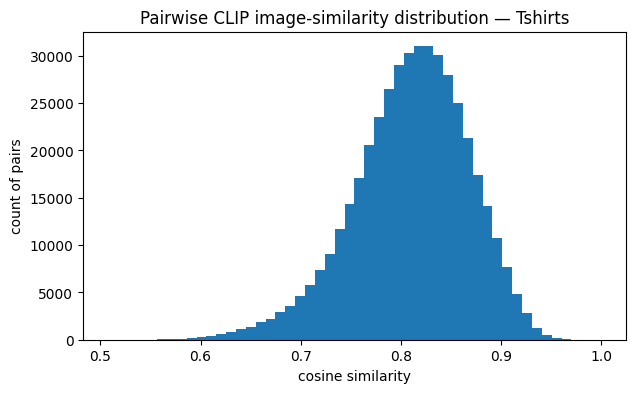

In [ ]:

sample_type = "Tshirts"
sample_df = df[df["articleType"] == sample_type].reset_index(drop=True)
sample_idxs = sample_df["embed_idx"].values
sample_embeds = image_embeddings[sample_idxs]
sample_sims = sample_embeds @ sample_embeds.T
upper_tri = sample_sims[np.triu_indices(len(sample_df), k=1)]

print(f"Pairwise similarity stats within '{sample_type}' (n={len(sample_df)} products):")
print(f"  mean={upper_tri.mean():.3f}  median={np.median(upper_tri):.3f}  "
      f"95th pct={np.percentile(upper_tri, 95):.3f}  99th pct={np.percentile(upper_tri, 99):.3f}  max={upper_tri.max():.3f}")

plt.figure(figsize=(7, 4))
plt.hist(upper_tri, bins=50)
plt.title(f"Pairwise CLIP image-similarity distribution — {sample_type}")
plt.xlabel("cosine similarity")
plt.ylabel("count of pairs")
plt.show()


In [ ]:
from collections import defaultdict
import difflib



IMAGE_SIM_THRESHOLD = 0.95   
NAME_SIM_THRESHOLD = 0.85    
                              
                             
                             

def name_similarity(a, b):
    return difflib.SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

def is_duplicate(row_i, row_j, img_sim):
    if img_sim < IMAGE_SIM_THRESHOLD:
        return False
    same_colour = row_i["baseColour"] == row_j["baseColour"]
    similar_name = name_similarity(row_i["productDisplayName"], row_j["productDisplayName"]) >= NAME_SIM_THRESHOLD
    return same_colour and similar_name

def find_duplicate_groups(sub_df, sub_embeds):
    """Group near-duplicate products WITHOUT transitive chaining.

    A naive union-find here is wrong: if A~B and B~C are both flagged as duplicate pairs,
    plain union-find would merge A and C into the same group even when A and C themselves
    are not duplicates (e.g. a derby and a monk-strap shoe both happen to be borderline-similar
    to a loafer in between, but not to each other). To avoid this "chaining" bug, a new item
    only joins an existing group if it is a duplicate of EVERY member already in that group
    (i.e. the group must stay a mutual-duplicate clique, not just a connected chain).
    """
    n = len(sub_df)
    sims = sub_embeds @ sub_embeds.T
    groups = []  

    for i in range(n):
        placed = False
        for group in groups:
            if all(is_duplicate(sub_df.iloc[i], sub_df.iloc[m], sims[i, m]) for m in group):
                group.append(i)
                placed = True
                break
        if not placed:
            groups.append([i])

    return groups


unique_rows = []
duplicate_report = []

for article_type, group_df in df.groupby("articleType"):
    idxs = group_df["embed_idx"].values
    sub_embeds = image_embeddings[idxs]
    groups = find_duplicate_groups(group_df.reset_index(drop=True), sub_embeds)

    for g in groups:
        group_global_idxs = idxs[g]
        rep_idx = group_global_idxs[0]
        unique_rows.append(rep_idx)
        if len(g) > 1:
            duplicate_report.append({
                "articleType": article_type,
                "group_size": len(g),
                "kept_id": int(df.loc[rep_idx, "id"]),
                "duplicate_ids": [int(df.loc[k, "id"]) for k in group_global_idxs[1:]],
            })

unique_catalog = df.loc[unique_rows].reset_index(drop=True)
print(f"Original catalog size: {len(df)}")
print(f"Unique catalog size:   {len(unique_catalog)}")
print(f"Duplicate groups found (size > 1): {len(duplicate_report)}")


Original catalog size: 6000
Unique catalog size:   5649
Duplicate groups found (size > 1): 277


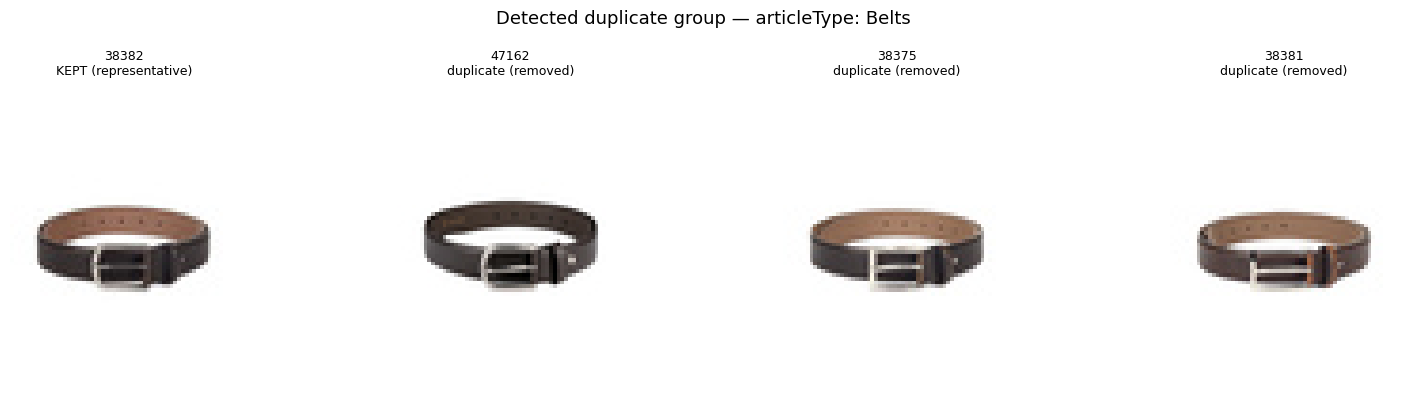

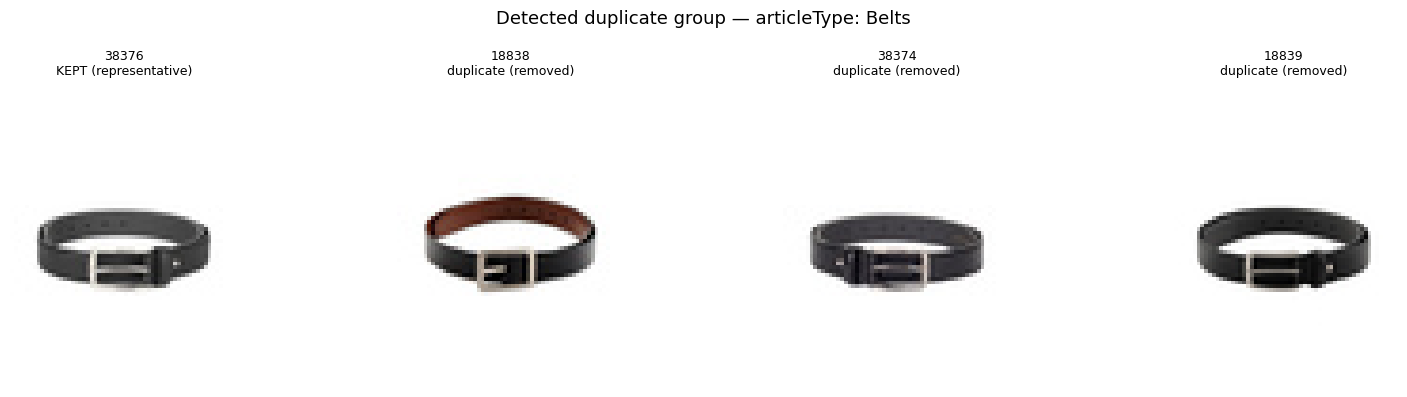

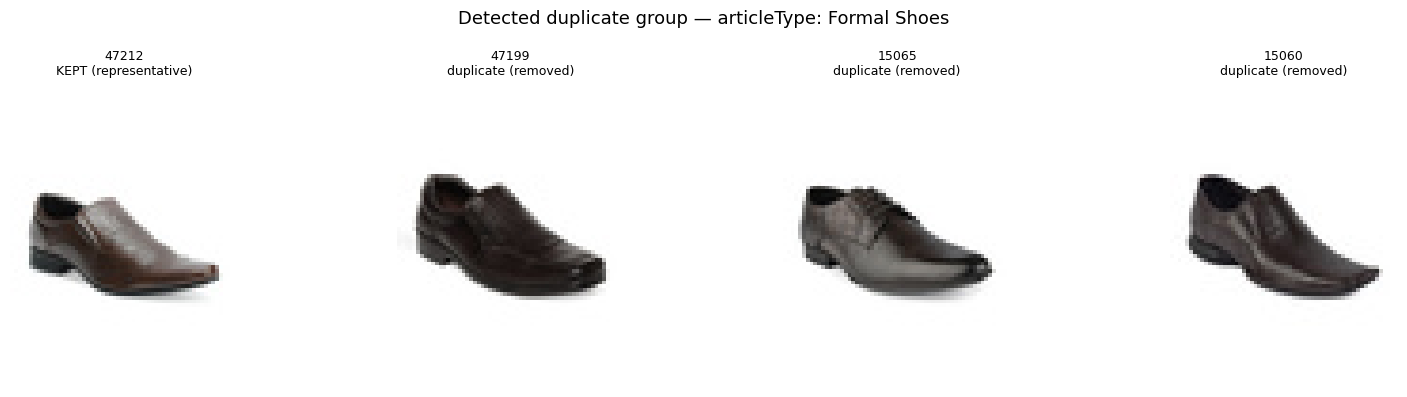

In [ ]:

def show_duplicate_group(report_row, max_show=4):
    ids_to_show = [report_row["kept_id"]] + report_row["duplicate_ids"][:max_show - 1]
    fig, axes = plt.subplots(1, len(ids_to_show), figsize=(4 * len(ids_to_show), 4))
    if len(ids_to_show) == 1:
        axes = [axes]
    fig.suptitle(f'Detected duplicate group — articleType: {report_row["articleType"]}', fontsize=13)
    for ax, pid in zip(axes, ids_to_show):
        row = df[df["id"] == pid].iloc[0]
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        tag = "KEPT (representative)" if pid == report_row["kept_id"] else "duplicate (removed)"
        ax.set_title(f'{pid}\n{tag}', fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


duplicate_report_sorted = sorted(duplicate_report, key=lambda r: -r["group_size"])
for report_row in duplicate_report_sorted[:3]:
    show_duplicate_group(report_row)


In [ ]:

unique_catalog[["id", "productDisplayName", "articleType", "baseColour"]].head(10)


,id,productDisplayName,articleType,baseColour
0,25055,Lino Perros Men Formal Brown Accessory Gift Set,Accessory Gift Set,Brown
1,25048,Lino Perros Men Formal Purple Accessory Gift Set,Accessory Gift Set,Purple
2,19936,Reid & Taylor Men Formal Brown Tie+Cufflink+Po...,Accessory Gift Set,Brown
3,25063,Lino Perros Men Formal Navy Blue/Red Accessory...,Accessory Gift Set,Navy Blue
4,25070,Lino Perros Men Formal Blue Accessory Gift Set,Accessory Gift Set,Blue
5,17368,Arrow Men Formal Maroon Tie+Cufflink+Pocket sq...,Accessory Gift Set,Maroon
6,17376,Arrow Men Formal Red Tie+Cufflink+Pocket squar...,Accessory Gift Set,Red
7,25076,Lino Perros Men Formal Black Accessory Gift Set,Accessory Gift Set,Black
8,58921,Hakashi Men Combo pack Tie+Cufflink+Pocket square,Accessory Gift Set,Multi
9,52477,Red Rose Black Nightdress,Baby Dolls,Black


---
## Task 1 — Smart Product Recommendation Engine (complementary products)

**Problem:** the existing system finds *visually similar* products (a running shoe to other running shoes). We want the opposite kind of recommendation: **complementary** products that are commonly bought *together* (a running shoe to socks, fitness watch, water bottle).

**Why CLIP image similarity alone can't do this:** visually similar embeddings cluster items that *look* alike, which is the wrong signal here — a sock and a shoe don't look alike at all, but they're a natural pair. So this task needs a different mechanism layered on top of the catalog.

**Approach used here — a category-affinity rule table:**
1. Define a small **co-purchase affinity map** between `articleType` categories (e.g. `Shoes -> [Socks, Sports Watch, ...]`), based on common real-world shopping patterns — this is the same idea as the "frequently bought together" logic e-commerce sites use, normally learned from real purchase logs. Since we don't have purchase-history data in this dataset, we encode this domain knowledge directly, which is a standard, honest substitute when transaction data isn't available.
2. For a given input product, look up its `articleType`'s complementary categories.
3. Within the catalog, **rank candidates within each complementary category by CLIP similarity to the input product's overall style/embedding**, so the recommendation isn't just "any shoe" but "a shoe-appropriate sock in a visually compatible style."


In [ ]:

COMPLEMENTARY_MAP = {
    "Shoes": ["Socks", "Sports Shoes", "Watches", "Backpacks"],
    "Sports Shoes": ["Socks", "Track Pants", "Sports Watches", "Water Bottle"],
    "Casual Shoes": ["Socks", "Casual Shirts", "Belts"],
    "Tshirts": ["Track Pants", "Casual Shoes", "Caps", "Backpacks"],
    "Shirts": ["Trousers", "Belts", "Casual Shoes", "Ties"],
    "Jeans": ["Tshirts", "Casual Shoes", "Belts"],
    "Trousers": ["Shirts", "Belts", "Formal Shoes"],
    "Dresses": ["Heels", "Clutches", "Earrings"],
    "Watches": ["Wallets", "Belts"],
    "Backpacks": ["Tshirts", "Casual Shoes", "Water Bottle"],
    "Sunglasses": ["Tshirts", "Casual Shoes", "Caps"],
}

available_types = set(df["articleType"].unique())
for k, v in COMPLEMENTARY_MAP.items():
    matched = [t for t in v if t in available_types]
    if k in available_types:
        print(f"{k:15s} -> {matched}")


Sports Shoes    -> ['Socks', 'Track Pants', 'Water Bottle']
Casual Shoes    -> ['Socks', 'Belts']
Tshirts         -> ['Track Pants', 'Casual Shoes', 'Caps', 'Backpacks']
Shirts          -> ['Trousers', 'Belts', 'Casual Shoes', 'Ties']
Jeans           -> ['Tshirts', 'Casual Shoes', 'Belts']
Trousers        -> ['Shirts', 'Belts', 'Formal Shoes']
Dresses         -> ['Heels', 'Clutches', 'Earrings']
Watches         -> ['Wallets', 'Belts']
Backpacks       -> ['Tshirts', 'Casual Shoes', 'Water Bottle']
Sunglasses      -> ['Tshirts', 'Casual Shoes', 'Caps']


In [ ]:
def recommend_complementary(product_id, top_k_per_category=3):
    if product_id not in df["id"].values:
        raise ValueError(f"Product id {product_id} not found.")

    row = df[df["id"] == product_id].iloc[0]
    article_type = row["articleType"]
    query_embed = image_embeddings[row["embed_idx"]]

    complementary_types = COMPLEMENTARY_MAP.get(article_type, [])
    if not complementary_types:
        print(f"No complementary mapping defined for articleType '{article_type}'.")
        return pd.DataFrame()

    recs = []
    for comp_type in complementary_types:
        candidates = df[df["articleType"] == comp_type]
        if len(candidates) == 0:
            continue
        cand_idxs = candidates["embed_idx"].values
        cand_embeds = image_embeddings[cand_idxs]
        sims = cand_embeds @ query_embed
        top_local = np.argsort(-sims)[:top_k_per_category]
        for li in top_local:
            global_row = candidates.iloc[li]
            recs.append({
                "id": int(global_row["id"]),
                "productDisplayName": global_row["productDisplayName"],
                "articleType": global_row["articleType"],
                "style_compatibility": float(sims[li]),
                "image_path": global_row["image_path"],
            })

    return pd.DataFrame(recs)


sample_shoe = df[df["articleType"].isin(["Sports Shoes", "Shoes"])].iloc[0]
print("Input product:", sample_shoe["productDisplayName"], "| id:", sample_shoe["id"])

recommendations = recommend_complementary(sample_shoe["id"])
recommendations


Input product: Puma Men Whirlwind Classic Green Sports Shoes | id: 15709


,id,productDisplayName,articleType,style_compatibility,image_path
0,15275,Nike Men Pack of 3 Sports Socks,Socks,0.807145,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,58291,Jockey LCESCBRA Men Pack of 3 Socks 2004,Socks,0.776962,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,18584,Puma Women Blue Pair of 2 Socks,Socks,0.766135,/kaggle/input/datasets/paramaggarwal/fashion-p...
3,7070,Timberland Men's Cycling Pod Chino Khaki Pant,Track Pants,0.772551,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,7486,Nike Women's Be Bold Navy Blue Track Pant,Track Pants,0.771470,/kaggle/input/datasets/paramaggarwal/fashion-p...
5,28519,Nike Men Breakline Black Track Pants,Track Pants,0.768613,/kaggle/input/datasets/paramaggarwal/fashion-p...
6,8958,Puma Unisex fundamentals Red Water Bottle,Water Bottle,0.661493,/kaggle/input/datasets/paramaggarwal/fashion-p...
7,8936,Puma Unisex fundamentals Black Water Bottle,Water Bottle,0.642935,/kaggle/input/datasets/paramaggarwal/fashion-p...


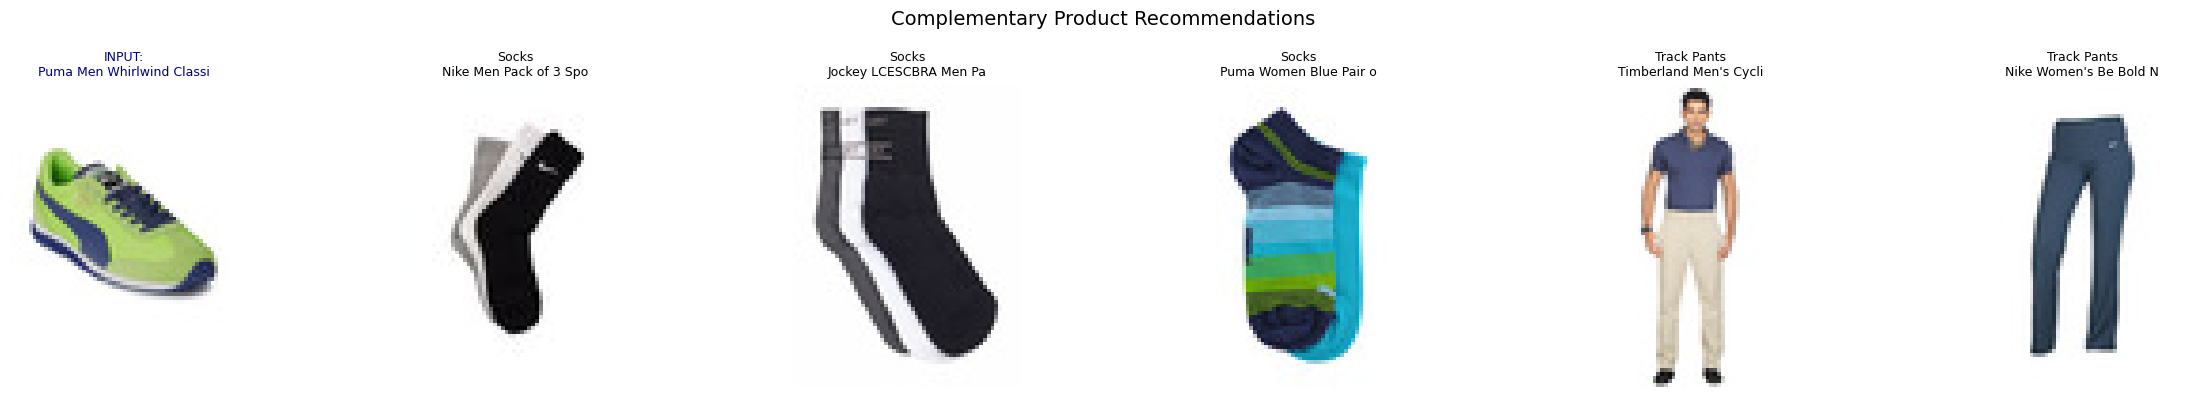

In [30]:
def show_recommendations(input_row, recs):
    n = len(recs) + 1
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    img = Image.open(input_row["image_path"]).convert("RGB")
    axes[0].imshow(img)
    axes[0].set_title(f'INPUT:\n{input_row["productDisplayName"][:25]}', fontsize=9, color="navy")
    axes[0].axis("off")

    for ax, (_, rec) in zip(axes[1:], recs.iterrows()):
        img = Image.open(rec["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f'{rec["articleType"]}\n{rec["productDisplayName"][:22]}', fontsize=9)
        ax.axis("off")

    plt.suptitle("Complementary Product Recommendations", fontsize=14)
    plt.tight_layout()
    plt.show()

show_recommendations(sample_shoe, recommendations.head(5))


---
## Summary

| Task | Technique | Output |
|---|---|---|
| Reverse Search | CLIP text-to-image embedding similarity | Top-K products matching a free-text query |
| Unique Catalog | CLIP image-embedding similarity + union-find clustering, scoped per `articleType` | Deduplicated catalog + a report of which IDs were merged |
| Recommendation Engine | Category-affinity rule table + CLIP similarity for style-consistent ranking within each complementary category | Complementary product suggestions for a given product |

**Shared foundation:** all three features build on the same CLIP embedding space computed once in Section 2 — this is the "extend the system" part of the brief: we didn't bolt on three unrelated tools, we reused the one embedding backbone three different ways.

**Honest limitation to note in the report:** the recommendation engine's affinity map is hand-authored here because this dataset has no purchase-history / co-occurrence data. In a real deployment, this table would be learned from actual "bought together" transaction logs (e.g. via market-basket analysis / association rule mining), with CLIP similarity used only for the final style-ranking step as done here.
